In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import scipy.io as sio
from dataclasses import dataclass
from typing import List, Tuple
import os
from dotenv import load_dotenv
load_dotenv()
import tidy3d as td
from tidy3d import web
import numpy as np
from pathlib import Path
from stl import mesh
import matplotlib.pyplot as plt
import re

In [2]:
import sys
import os

# Assuming /AutomationModule is in the root directory of your project
sys.path.append(os.path.abspath(fr'H:\phd stuff\tidy3d'))

from AutomationModule import * 

import AutomationModule as AM

In [3]:
tidy3dAPI = os.environ["API_TIDY3D_KEY"]


In [4]:
lambdas = np.array([10,2.5])
sphere,phi,theta=AM.get_sphere(1000)
run = True


Configured successfully.


15:02:54 W. Europe Standard Time WARNING: Structure at 'structures[0]' has      
                                 bounds that extend exactly to simulation edges.
                                 This can cause unexpected behavior. If         
                                 intending to extend the structure to infinity  
                                 along one dimension, use td.inf as a size      
                                 variable instead to make this explicit.        

                                 WARNING: Suppressed 3 WARNING messages.        

15:02:55 W. Europe Standard Time WARNING: Monitor 'field_monitor' estimated     
                                 storage is 19.20GB. Consider making it smaller,
                                 using fewer frequencies, or spatial or temporal
                                 downsampling using 'interval_space' and        
                                 'interval', respectively.                      

15:02:56 W. Europe Standard Time Created task                                   
                                 'LSU_n_3.30_ff_0.2237_size_0.03496503496503496'
                                 with task_id                                   
                                 'fdve-6598b8e0-b4a9-4ee9-948c-f4a137e625e0' and
                                 task_type 'FDTD'.

...

Output()

Output()

15:23:46 W. Europe Standard Time status = postprocess

15:26:10 W. Europe Standard Time status = success

15:26:12 W. Europe Standard Time View simulation result at                      
                                 ]8;id=647305;https://tidy3d.simulation.cloud/workbench?taskId=fdve-6598b8e0-b4a9-4ee9-948c-f4a137e625e0\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=388559;https://tidy3d.simulation.cloud/workbench?taskId=fdve-6598b8e0-b4a9-4ee9-948c-f4a137e625e0\task]8;;\
                                 ]8;id=388559;https://tidy3d.simulation.cloud/workbench?taskId=fdve-6598b8e0-b4a9-4ee9-948c-f4a137e625e0\Id]8;;\]8;id=647305;https://tidy3d.simulation.cloud/workbench?taskId=fdve-6598b8e0-b4a9-4ee9-948c-f4a137e625e0\=]8;;\]8;id=797631;https://tidy3d.simulation.cloud/workbench?taskId=fdve-6598b8e0-b4a9-4ee9-948c-f4a137e625e0\fdve]8;;\]8;id=647305;https://tidy3d.simulation.cloud/workbench?taskId=fdve-6598b8e0-b4a9-4ee9-948c-f4a137e625e0\-6598b8e0-b4a9-4ee9-948c-f4a137e625e0']8;;\.

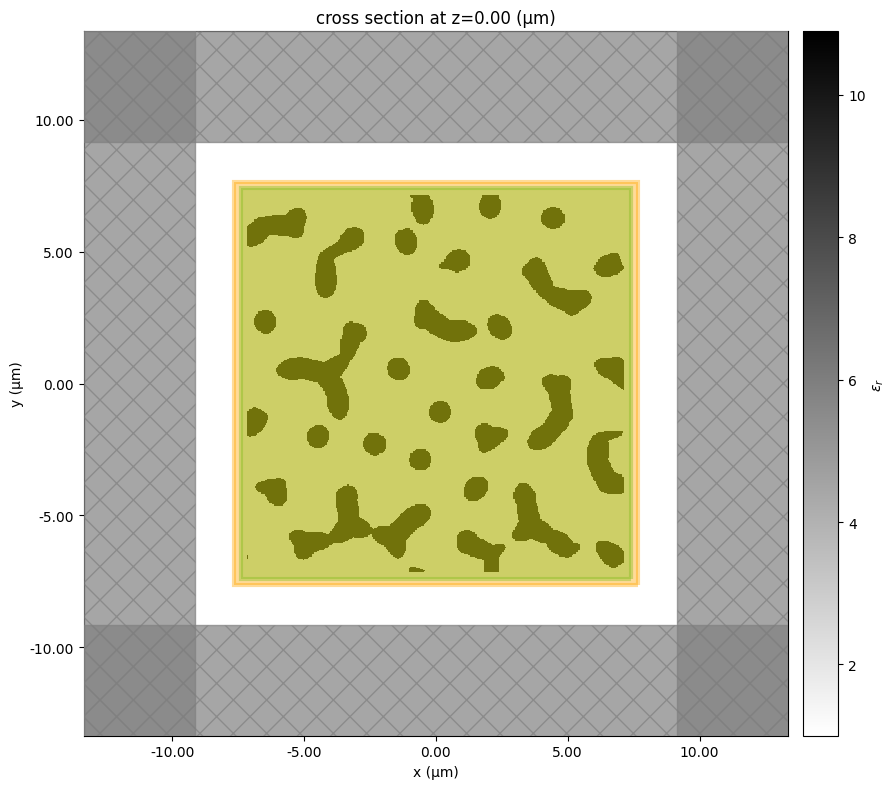

In [5]:
from pdb import run


folder_path = rf"../Structures"
project_name = "20260224_LSU_get_g_factor"
postprocess_results = []
runtime_ps = 20e-12
min_steps_per_lambda = 18
cuts=[0.5/14.3]
h5_bg = None
ref = True
for direction in ["z"]: 
    for dirpath, dirnames, filenames in os.walk(folder_path):
        try:
            for filename in filenames:
                if filename.endswith(".h5"):
                    ff = float(re.search(r'ff_([+-]?\d+(?:\.\d+)?)', filename).group(1))
                    n_value = float(re.search(r'n_([+-]?\d+(?:\.\d+)?)', filename).group(1))
                    if ff>0.23:
                        continue
                    for cut in cuts:
                        if not (Path(filename).suffix==".h5" or Path(filename).suffix==".stl"):
                            continue 
                        if os.path.isfile(os.path.join(dirpath, filename)):
                            file=os.path.join(dirpath, filename)
                            structure_1 = AM.loadAndRunStructure(key = tidy3dAPI, file_path=file
                                                            ,direction=direction, lambda_range=lambdas,
                                                            box_size=14.3,runtime_ps=runtime_ps,min_steps_per_lambda=min_steps_per_lambda,
                                                           scaling=1,shuoff_condtion=1e-20, verbose=True, 
                                                           monitors=[], flux_monitor_position=18,cell_size_manual=20,#multiplication_factor=2,multiplicate_size=True,
                                                           freqs=400, boundaries="absorbers",
                                                           cut_condition=cut, source="planewave", absorbers=100, use_permittivity=False,sim_name=rf"{Path(filename).stem}_size_{cut}" + (rf"_bg_{h5_bg}" if h5_bg else ""),h5_bg=h5_bg,
                                                           )
                            sim=structure_1.sim
                            monitor_field = td.FieldProjectionAngleMonitor(
                                    center=[0.0, 0.0, 0.0],
                                    
                                    size=(structure_1.t_slab_x+1, structure_1.t_slab_y+1, structure_1.t_slab_z+1),
                                    name="field_monitor",
                                    freqs =structure_1.monitor_freqs,
                                    phi=list(phi),
                                    theta=list(theta),
                                    proj_distance=1e6,  # Set a very large projection distance to approximate far-field conditions
                                    far_field_approx=True, 
                                        )
                            source = td.TFSF(
                                center=(0, 0, 0),
                                size=(structure_1.t_slab_x+0.5, structure_1.t_slab_y+0.5, structure_1.t_slab_z+0.5),
                                source_time=structure_1.gaussian_pulse,
                                injection_axis=2,  # inject along the z axis...
                                direction="+",  # ...in the positive direction, i.e. along z+
                                name="tfsf1",
                                pol_angle=0,
                            )
                            sim=sim.copy(update={"size":(structure_1.t_slab_x+4, structure_1.t_slab_y+4, structure_1.t_slab_z+4),"monitors":[monitor_field],"sources":[source],"grid_spec":td.GridSpec.uniform(structure_1.dl)})
                            folder_desc = rf"H:\phd stuff\tidy3d\data\{project_name}\n_{n_value:.2f}"
                            sim.plot_3d()
                            fig, ax = plt.subplots(1, tight_layout=True, figsize=(16, 8))
                            sim.plot_eps(z=0, freq=structure_1.monitor_freqs[0], ax=ax)
                            if run:
                                os.makedirs(folder_desc, exist_ok=True)
                                sim_name=rf"LSU_{Path(filename).stem}_size_{cut}"
                                if os.path.exists(os.path.join(folder_desc, sim_name+".txt")):
                                    print("Exist!")
                                else:
                                    id =web.upload(sim, folder_name=project_name,task_name=sim_name, verbose=True)
                                    ids = '\n' + id
                                    with open(os.path.join(folder_desc, sim_name+".txt"), "w") as file:
                                        # Write the string to the file
                                        file.write(ids)
                                    web.start(task_id = id)
                                    web.monitor(id)
                            

        except Exception as e:
            print(f"Error processing {dirpath}: {e}")
        
    

